In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

In [2]:
df = pd.read_csv("processed_telco.csv")

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,IsLongTermCustomer
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,14.925000,2,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,53.985714,3,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,36.050000,3,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.016304,4,1
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,50.550000,1,0


In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [6]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4930, 33)
Validation: (1056, 33)
Test: (1057, 33)


In [7]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [8]:
y_val_pred = lr.predict(X_val)

In [9]:
accuracy_score(
    y_val,
    y_val_pred
)

0.7433712121212122

In [10]:
precision_score(
    y_val,
    y_val_pred
)

0.5099778270509978

In [11]:
recall_score(
    y_val,
    y_val_pred
)

0.8214285714285714

In [12]:
f1_score(
    y_val,
    y_val_pred
)

0.6292749658002736

In [13]:
print(
    classification_report(
        y_val,
        y_val_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.72      0.80       776
           1       0.51      0.82      0.63       280

    accuracy                           0.74      1056
   macro avg       0.71      0.77      0.72      1056
weighted avg       0.81      0.74      0.76      1056



In [14]:
cm = confusion_matrix(
    y_val,
    y_val_pred
)

cm

array([[555, 221],
       [ 50, 230]])

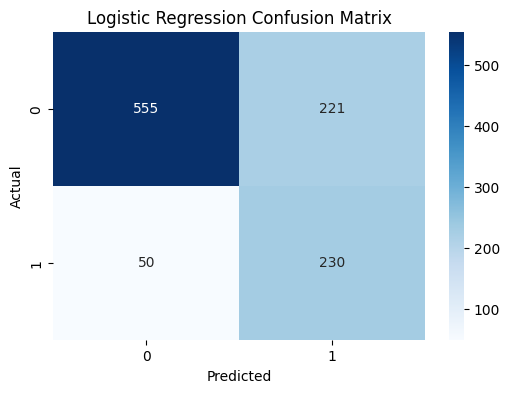

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [16]:
y_prob = lr.predict_proba(
    X_val
)[:,1]

roc_auc_score(
    y_val,
    y_prob
)

np.float64(0.849951675257732)

Logistic Regression achieved an accuracy of 74.34% and a ROC-AUC score of 84.99%. The model demonstrated strong recall (82.14%), indicating that it effectively identified customers likely to churn. This makes it suitable as a baseline churn prediction model.

In [18]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

In [19]:
grid_lr = GridSearchCV(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [20]:
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest F1 Score:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 1, 'solver': 'lbfgs'}

Best F1 Score:
0.6363447000131743


GridSearchCV was used to optimize Logistic Regression hyperparameters. The best parameters were C=1 and solver='lbfgs'. The optimized model achieved a cross-validation F1 score of 0.6363, indicating a balanced performance between precision and recall.

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_val_pred_dt = dt.predict(X_val)

In [23]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_dt))
print("Precision:", precision_score(y_val, y_val_pred_dt))
print("Recall:", recall_score(y_val, y_val_pred_dt))
print("F1 Score:", f1_score(y_val, y_val_pred_dt))

Accuracy: 0.7263257575757576
Precision: 0.4845360824742268
Recall: 0.5035714285714286
F1 Score: 0.4938704028021016


Decision Tree achieved an accuracy of 72.63%. However, its recall and F1 score were lower than Logistic Regression, indicating that it was less effective at identifying churn customers. Therefore, Logistic Regression currently performs better for churn prediction.

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)

In [26]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall:", recall_score(y_val, y_val_pred_rf))
print("F1 Score:", f1_score(y_val, y_val_pred_rf))

Accuracy: 0.7784090909090909
Precision: 0.5991379310344828
Recall: 0.49642857142857144
F1 Score: 0.54296875


Random Forest achieved the highest accuracy (77.84%) and precision (59.13%). However, Logistic Regression achieved a significantly higher recall (82.14%), making it more effective at identifying customers who are likely to churn. For churn prediction, Logistic Regression currently provides the best balance between business value and predictive performance.

In [27]:
from sklearn.svm import SVC

In [28]:
svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

y_val_pred_svm = svm.predict(X_val)

In [29]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("Precision:", precision_score(y_val, y_val_pred_svm))
print("Recall:", recall_score(y_val, y_val_pred_svm))
print("F1 Score:", f1_score(y_val, y_val_pred_svm))

Accuracy: 0.6685606060606061
Precision: 0.4116161616161616
Recall: 0.5821428571428572
F1 Score: 0.4822485207100592


SVM achieved an accuracy of 66.86% and an F1 score of 48.22%. Compared to Logistic Regression and Random Forest, SVM showed lower predictive performance on the churn dataset. Therefore, it was not selected as the best-performing model.

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

y_val_pred_knn = knn.predict(X_val)

In [32]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_knn))
print("Precision:", precision_score(y_val, y_val_pred_knn))
print("Recall:", recall_score(y_val, y_val_pred_knn))
print("F1 Score:", f1_score(y_val, y_val_pred_knn))

Accuracy: 0.7623106060606061
Precision: 0.5674418604651162
Recall: 0.4357142857142857
F1 Score: 0.49292929292929294


**Comparison**

In [33]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'KNN'
    ],
    'Accuracy': [
        0.7434,
        0.7263,
        0.7784,
        0.6686,
        0.7623
    ],
    'Precision': [
        0.5100,
        0.4845,
        0.5913,
        0.4116,
        0.5674
    ],
    'Recall': [
        0.8214,
        0.5036,
        0.4964,
        0.5821,
        0.4357
    ],
    'F1 Score': [
        0.6293,
        0.4939,
        0.5430,
        0.4822,
        0.4929
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7434,0.5100,0.8214,0.6293
1,Decision Tree,0.7263,0.4845,0.5036,0.4939
2,Random Forest,0.7784,0.5913,0.4964,0.5430
3,SVM,0.6686,0.4116,0.5821,0.4822
4,KNN,0.7623,0.5674,0.4357,0.4929


Logistic Regression is selected as the best model.

Among all classification models, Logistic Regression was selected as the best-performing model. Although Random Forest achieved the highest accuracy, Logistic Regression achieved the highest recall (82.14%), highest F1 score (62.93%), and a strong ROC-AUC score (84.99%). Since customer churn prediction prioritizes identifying customers likely to leave, Logistic Regression provides the most business value.